<a href="https://colab.research.google.com/github/alnajenson252dot/ict_assigntment/blob/main/Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
data = pd.read_csv('/content/bank-additional-full (1).csv')

In [12]:
data.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [14]:
numerical_cols = data.select_dtypes(include=np.number).columns.tolist()
categorical_cols = data.select_dtypes(include='object').columns.tolist()

In [15]:
print(f"\nNumerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")


Numerical columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


In [16]:
print("Distribution of target variable 'y':\n", data['y'].value_counts())
print("\nPercentage distribution of target variable 'y':\n", data['y'].value_counts(normalize=True) * 100)

Distribution of target variable 'y':
 y
no     36548
yes     4640
Name: count, dtype: int64

Percentage distribution of target variable 'y':
 y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


/tmp/ipykernel_1599/1958746766.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='y', data=data, palette='viridis')


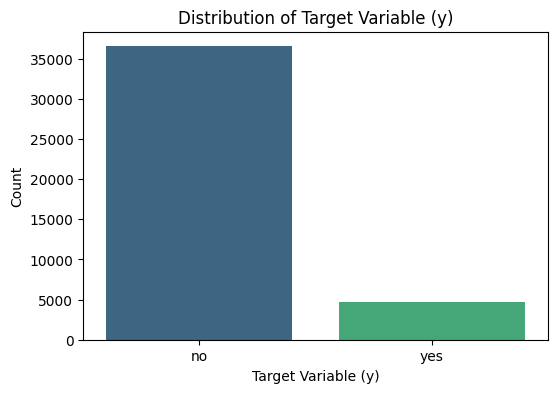

In [17]:
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=data, palette='viridis')
plt.title('Distribution of Target Variable (y)')
plt.xlabel('Target Variable (y)')
plt.ylabel('Count')
plt.show()

In [18]:
for col in categorical_cols:
    if 'unknown' in data[col].unique():
        print(f"Column '{col}' contains 'unknown' values.")
        print(data[col].value_counts())
        print("\n")

Column 'job' contains 'unknown' values.
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64


Column 'marital' contains 'unknown' values.
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64


Column 'education' contains 'unknown' values.
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64


Column 'default' contains 'unknown' values.
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64


Column 'housing' contains 'unknown' values.
housing
y

In [19]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [20]:
X = data.drop('y', axis=1)
y = data['y']

In [21]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [22]:
categorical_features_for_ohe = [col for col in categorical_cols if col != 'y']

In [23]:

ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features_for_ohe)],remainder='passthrough')
X_encoded = ct.fit_transform(X)

In [24]:
ohe_feature_names = ct.named_transformers_['encoder'].get_feature_names_out(categorical_features_for_ohe)

In [25]:
remaining_numerical_cols = [col for col in X.columns if col not in categorical_features_for_ohe]

In [26]:
all_feature_names = list(ohe_feature_names) + list(remaining_numerical_cols)

In [27]:
X_processed = pd.DataFrame(X_encoded, columns=all_feature_names)
display(X_processed.head())

,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,56.0,261.0,1.0,999.0,0.0,1.1,93.994,-36.4,4.857,5191.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,57.0,149.0,1.0,999.0,0.0,1.1,93.994,-36.4,4.857,5191.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,37.0,226.0,1.0,999.0,0.0,1.1,93.994,-36.4,4.857,5191.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,40.0,151.0,1.0,999.0,0.0,1.1,93.994,-36.4,4.857,5191.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,56.0,307.0,1.0,999.0,0.0,1.1,93.994,-36.4,4.857,5191.0


In [28]:
from sklearn.preprocessing import StandardScaler

In [29]:
numerical_cols_processed = X_processed[numerical_cols].columns

In [30]:
scaler = StandardScaler()

In [31]:
X_processed[numerical_cols_processed] = scaler.fit_transform(X_processed[numerical_cols_processed])
display(X_processed.head())

,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.533034,0.010471,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.628993,-0.421501,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.290186,-0.124520,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.002309,-0.413787,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.533034,0.187888,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168


In [32]:
X_train, X_test, y_train, y_test = train_test_split(X_processed, y_encoded, test_size=0.3, random_state=42)

In [33]:
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (28831, 63)
Shape of X_test: (12357, 63)
Shape of y_train: (28831,)
Shape of y_test: (12357,)


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    start_time = time.time()
    y_pred = model.predict(X_test)
    predict_time = time.time() - start_time

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        'accuracy': accuracy,
        'classification_report': report,
        'confusion_matrix': cm,
        'train_time': train_time,
        'predict_time': predict_time
    }

    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:\n", report)
    print("Confusion Matrix:\n", cm)
    print(f"Training Time: {train_time:.4f} seconds")
    print(f"Prediction Time: {predict_time:.4f} seconds")


--- Training Logistic Regression ---
Accuracy: 0.9123
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95     10968
           1       0.68      0.42      0.52      1389

    accuracy                           0.91     12357
   macro avg       0.80      0.70      0.74     12357
weighted avg       0.90      0.91      0.90     12357

Confusion Matrix:
 [[10685   283]
 [  801   588]]
Training Time: 0.4451 seconds
Prediction Time: 0.0069 seconds

--- Training K-Nearest Neighbors ---
Accuracy: 0.9014
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.95     10968
           1       0.59      0.42      0.49      1389

    accuracy                           0.90     12357
   macro avg       0.76      0.69      0.72     12357
weighted avg       0.89      0.90      0.89     12357

Confusion Matrix:
 [[10553   415]
 [  803   586]]
Training Time: 0.0431 seco

In [ ]:
metrics_summary = []
for name, model_results in results.items():
    report_lines = model_results['classification_report'].split('\n')
    # Extract overall metrics from the weighted avg line
    for line in report_lines:
        if 'weighted avg' in line:
            parts = line.split()
            if len(parts) >= 5:
                precision = float(parts[2])
                recall = float(parts[3])
                f1_score = float(parts[4])
                break
    else:
        precision, recall, f1_score = np.nan, np.nan, np.nan # Fallback if not found

    metrics_summary.append({
        'Model': name,
        'Accuracy': model_results['accuracy'],
        'Precision (weighted avg)': precision,
        'Recall (weighted avg)': recall,
        'F1-Score (weighted avg)': f1_score,
        'Training Time (s)': model_results['train_time'],
        'Prediction Time (s)': model_results['predict_time']
    })

metrics_df = pd.DataFrame(metrics_summary)
metrics_df = metrics_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

display(metrics_df)

In [ ]:
metrics_summary = []
for name, model_results in results.items():
    report_lines = model_results['classification_report'].split('\n')
    # Extract overall metrics from the weighted avg line
    for line in report_lines:
        if 'weighted avg' in line:
            parts = line.split()
            if len(parts) >= 5:
                precision = float(parts[2])
                recall = float(parts[3])
                f1_score = float(parts[4])
                break
    else:
        precision, recall, f1_score = np.nan, np.nan, np.nan # Fallback if not found

    metrics_summary.append({
        'Model': name,
        'Accuracy': model_results['accuracy'],
        'Precision (weighted avg)': precision,
        'Recall (weighted avg)': recall,
        'F1-Score (weighted avg)': f1_score,
        'Training Time (s)': model_results['train_time'],
        'Prediction Time (s)': model_results['predict_time']
    })

metrics_df = pd.DataFrame(metrics_summary)
metrics_df = metrics_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

display(metrics_df)

In [ ]:

best_model_name = metrics_df.loc[0, 'Model']
best_model = models[best_model_name]


if hasattr(best_model, 'feature_importances_'):
    feature_importances = pd.Series(best_model.feature_importances_, index=X_processed.columns)
    top_features = feature_importances.nlargest(15) # Display top 15 features

    plt.figure(figsize=(12, 8))
    sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
    plt.title(f'Top 15 Feature Importances for {best_model_name}')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()
elif hasattr(best_model, 'coef_'):

    feature_importances = pd.Series(best_model.coef_[0], index=X_processed.columns)

    top_features = feature_importances.abs().nlargest(15)

    plt.figure(figsize=(12, 8))
    sns.barplot(x=top_features.values, y=feature_importances.loc[top_features.index].index, palette='viridis')
    plt.title(f'Top 15 Feature Influences (Absolute Coefficients) for {best_model_name}')
    plt.xlabel('Absolute Coefficient Value')
    plt.ylabel('Feature')
    plt.show()
else:
    print(f"Feature importances are not directly available for {best_model_name}.")